This is my attempt of applying edge detection techniques without major lib functions

(1477, 1108, 3)
[99 70 30]


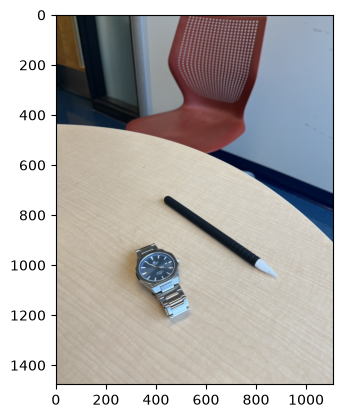

In [177]:
import pandas as pd
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import math

img = mpimg.imread('test.jpg')
print(img.shape)
print(img[0][0]) # [R G B]
plt.imshow(img)

To grey scale the image, we just take the R channel

(1477, 1108)
99


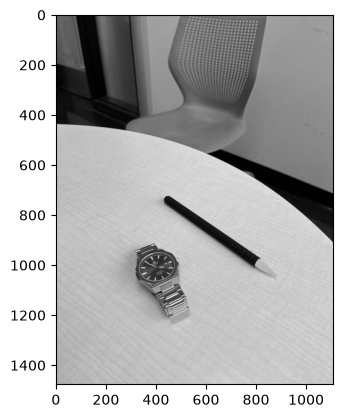

In [178]:
# to grey scale
grey_img = np.dot(img[..., :3], [1, 0, 0])
print(grey_img.shape)
print(grey_img[0][0])
plt.imshow(grey_img, cmap='gray')

### Without Gaussian Smoothing

Horizontal filter [1, 0, -1]

[Taichi] Starting on arch=x64
(1477, 1108)


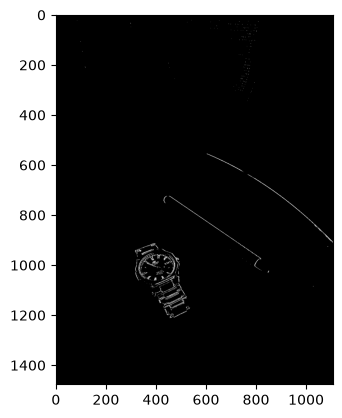

In [179]:
import taichi as ti
ti.init(arch=ti.cpu)

hor1D_img = np.zeros_like(grey_img)
@ti.kernel
def edge_horizontal(img: ti.types.ndarray(),
                    out: ti.types.ndarray(),
                    threshold: ti.types.float32):
    '''
    Using the filter [1 0 -1] on x = {-1, 0, 1} with no padding
    '''
    height = img.shape[0] 
    width = img.shape[1]

    for i in range(1, height-1):
        for j in range(1, width-1):
            out[i, j] = img[i, j-1] - img[i, j+1]
            if abs(out[i, j]) > threshold:
                out[i, j] = 1
            else:
                out[i, j] = 0

edge_horizontal(grey_img, hor1D_img, 50)
print(hor1D_img.shape)
plt.imshow(hor1D_img, cmap='gray')

Vertical

(1477, 1108)


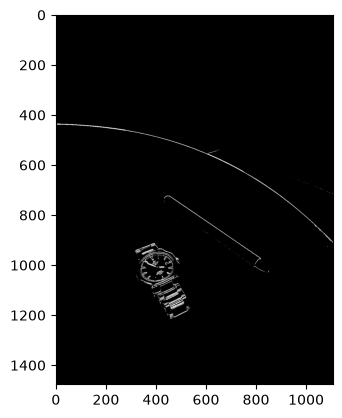

In [180]:
vert1D_img = np.zeros_like(grey_img)
@ti.kernel
def edge_vertical(img: ti.types.ndarray(),
                    out: ti.types.ndarray(),
                    threshold: ti.types.float32):
    '''
    Using the filter [1 0 -1] on y = {-1, 0, 1} with no padding
    '''
    height = img.shape[0] 
    width = img.shape[1]

    for i in range(1, height - 1):
        for j in range(1, width - 1):
            out[i, j] = img[i-1, j] - img[i+1, j]
            if abs(out[i, j]) > threshold:
                out[i, j] = 1
            else:
                out[i, j] = 0

edge_vertical(grey_img, vert1D_img, 50)
print(vert1D_img.shape)
plt.imshow(vert1D_img, cmap='gray')

Prewitt: Using horizontal and vertical together

(1477, 1108)


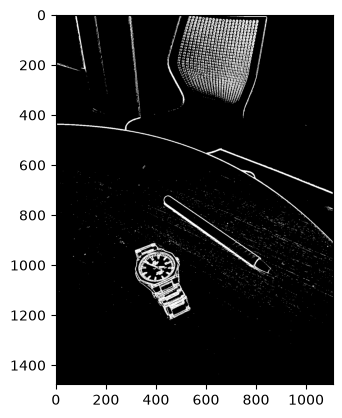

In [181]:
prewitt_img = np.zeros_like(grey_img)
@ti.kernel
def Prewitt(img: ti.types.ndarray(),
                    out: ti.types.ndarray(),
                    threshold: ti.types.float32):
    '''
    Using the filter [1 0 -1] on y = {-1, 0, 1} with no padding
    '''
    height = img.shape[0] 
    width = img.shape[1]

    for i in range(1, height - 1):
        for j in range(1, width - 1):
            dx = ((img[i, j-1] - img[i, j+1]) +
                  (img[i-1, j-1] - img[i-1, j+1]) + 
                  (img[i+1, j-1] - img[i+1, j+1]))
            dy = ((img[i-1, j] - img[i+1, j]) + 
                  (img[i-1, j+1] - img[i+1, j+1]) + 
                  (img[i-1, j-1] - img[i+1, j-1]))
            gradient = ti.sqrt((dx * dx + dy * dy))
            if gradient > threshold:
                out[i, j] = 1
            else:
                out[i, j] = 0

Prewitt(grey_img, prewitt_img, 50)
print(prewitt_img.shape)
plt.imshow(prewitt_img, cmap='gray')

There's too many noise/details now. Let's try smoothing the image first.

(1477, 1108)
(1477, 1108)


Text(0.5, 1.0, 'With smoothing')

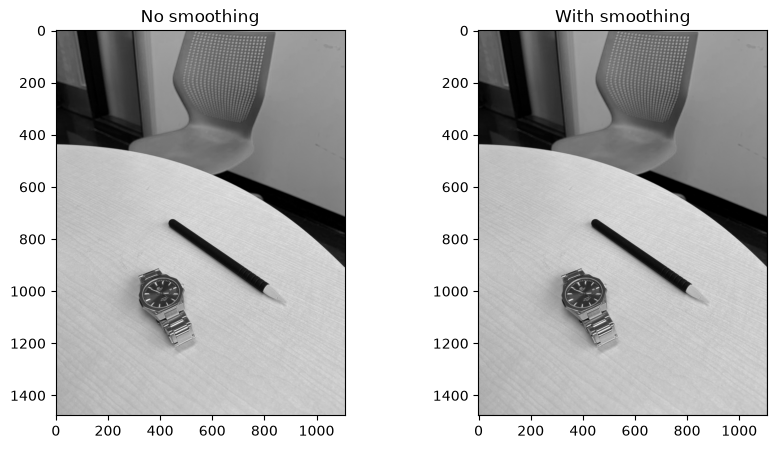

In [191]:
img_smoothed = np.zeros_like(grey_img)
print(img_smoothed.shape)
@ti.func
def GD(x, y, sigma):
    ''' Gaussian Distribution
    '''
    return (1/(2 * math.pi * sigma * sigma)) * ti.pow(math.e, -(x * x + y * y)/(2 * sigma * sigma))

@ti.kernel
def GaussianSmoothing(img: ti.types.ndarray(),
                      out: ti.types.ndarray(),
                      sigma: ti.types.float32):
    height = img.shape[0]
    width = img.shape[1]

    for i in range(1, height - 1):
        for j in range(1, width - 1):
            weight_sum = 0
            for u in range(-1, 2):
                for v in range(-1, 2):
                    weight = GD(u, v, sigma)
                    weight_sum += weight
                    out[i, j] += img[i + u, j + v] * weight
            out[i, j] / weight_sum
GaussianSmoothing(grey_img, img_smoothed, 0.2)
print(img_smoothed.shape)
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(grey_img, cmap='gray')
axes[0].set_title("No smoothing")
axes[1].imshow(img_smoothed, cmap='gray')
axes[1].set_title("With smoothing")

Text(0.5, 1.0, 'With smoothing')

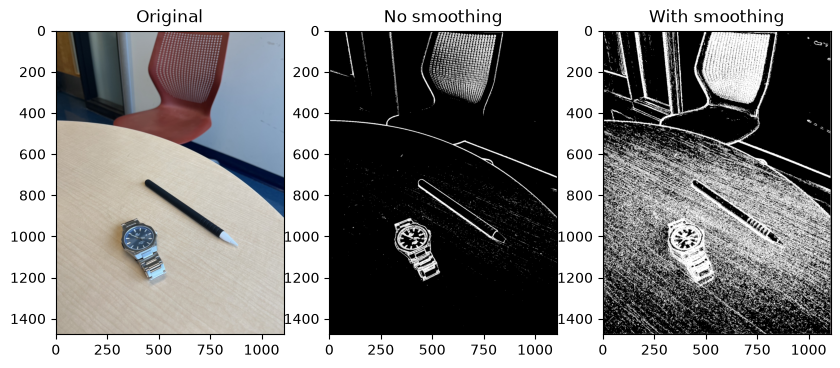

In [192]:
smoothed_prewitt = np.zeros_like(prewitt_img)
Prewitt(img_smoothed, smoothed_prewitt, 50)

fig, axes = plt.subplots(1, 3, figsize=(10,5))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[1].imshow(prewitt_img, cmap='gray')
axes[1].set_title("No smoothing")
axes[2].imshow(smoothed_prewitt, cmap='gray')
axes[2].set_title("With smoothing")